<a href="https://colab.research.google.com/github/HolaBaGa/tibame/blob/main/%E7%88%AC%E8%9F%B2%E6%8A%93%E5%8B%95%E7%95%AB%E7%98%8B%E5%BD%88%E5%B9%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

5/16 影片 2:20:38 開始


小知識

動畫瘋鎖海外IP, 而Colab在美國, 因此沒辦法用colab 載

In [ ]:
import urllib.request as req
# urllib.request 是內建用來開啟 URLs 的可擴充函式庫
# list + duct: JSON格式

url = "https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK"
f = req.urlopen(url)
# 送出網址
content = f.read()
# 讀取網址
print(content)
# 印出網址, 遠端開啟的概念
# 輸出後的\u8b9a\ 是萬國碼(Unicode)表示的中文

print(type(content))
# 確認型態, 輸出 'bytes'為 0與1的組合, 可當成原始字串, 字典外面會寫b做提示
# 輸出後的 \u 開頭是Unicode 編碼（萬國編碼）代表原始內容是中文

python語法

動詞+s 表示為字串, 中文叫load的字串

參數+s 也是為字串

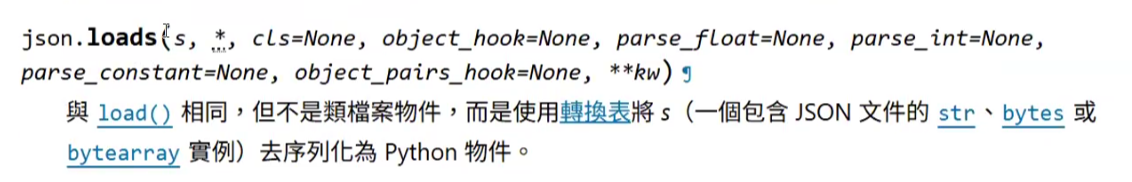

In [ ]:
# 本欄重點, 確認型態是否有轉換, 輸出從萬國碼改為字典

import json
import urllib.request as req

url = "https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK"
f = req.urlopen(url)
content = f.read()
print(type(content))
print(content)
content = json.loads(content)
# json.loads python 型態轉換的語法

print(type(content))
print(content)


In [ ]:
# 本欄重點, 拿到條列式的彈幕

import json
import urllib.request as req

url = "https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK"
f = req.urlopen(url)
content = f.read()
content = json.loads(content)
# content 字典

danmus = content["data"]["danmu"]
# 拿出字典中 ["data"], ["danmu"]的清單
for d in danmus:
# 從 danmus 清單中拿出一個彈幕字典，並把這個字典暫時命名為 d
    print(d["userid"], d["text"])
    # 印出d的id(字典的key),d的文字(字典的key)
    # 迴圈把資料「拆包」，逐一取出並自動換行，變成乾淨、好讀的格式


格式彙整!!!

JSON格式: [] + {}
CSV標準表格格式
HTML格式

CSV(Comma-Separated Values)
CSV標準表格格式 (用"," 分隔每一個值, 留意逗號/換行/雙引號的用法)
* 攣生兄弟: TSV (用TAB分隔每一個值)

CSV範例

姓名,身高

Elwing,175

"Bob, Mr. Chou",180

注意:
* execel 不要用, 因不是用萬國編碼, 建議用google sheet (萬國編碼utf-8 )
這樣不論蘋果或是 Linux  都可以正常使用
而365出是為了解決編碼的問題
* 大五碼 (Big5)最普及的繁體中文字元集標準，主要使用於台灣、香港與澳門
* GBK 編碼 簡體中文

```
HTML格式: 無數個長方形區塊所構成
<> 開始

</> 結束

超連結
<a href="網址">
    請點我
</a>


1. 名字: 決定他是什麼
a: 超連結, img: 圖片, video: 影片

2. 屬性: 決定細節(key="value")
a href="網址"  -> 超連結連到外面, 所以是Hypertext Reference
img video src="網址" -> 把網址的東西載到現在的頁面

3. 顯示的內容

下圖範例解釋
<.....> 開始
a 名字超連結
href= ... 47429 : 屬性
32 : 內容
</a> 結束
```



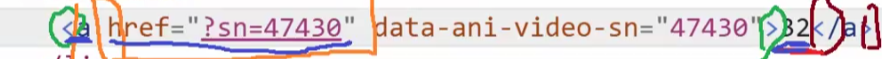

In [ ]:
# 生成一個.csv的檔案
# 一般寫法, 最後要寫colse, 與高級寫法各有各的好

f = open("test.csv", "w", encoding="utf-8")
# "w" 表示寫入
# 打開叫f

f.write("姓名,身高\n")
#  "\"逃脫字元+"n" = \n表示換行,不能用enter會變成編輯器的換行
f.write("Elwing,175\n")
f.write('"Bob,Mr.Chou",180')
# 注意'跟"用法, 如果字串裡面一定要有""雙引號, 外面就要用''單引號, 作定義字串
# 最後結尾不用換行
f.close()

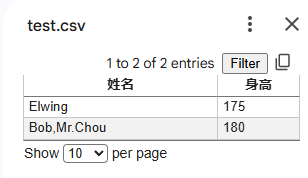

In [ ]:
# 高級寫法
# with as: 會自動幫你close
with open("test.csv", "w", encoding="utf-8") as f:
    f.write("姓名,身高\n")
    f.write("Elwing,175\n")
    f.write('"Bob,Mr.Chou",180')

In [ ]:
#最後銜接

import json
import urllib.request as req
import pandas as pd
# as 後面的名稱是淺規則, 大家都這樣說, 如果沒有寫, 其他人會運行錯誤
# colab 會自動安裝常用的第三方程式, 如果剛好沒有, 使用!pip install pandas , !表命令列指令
# pandas 表格很好用
# !是跳脫python, 使用終端機

# list + dict: JSON格式
url = "https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK"
f = req.urlopen(url)
content = f.read()
content = json.loads(content)

danmus = content["data"]["danmu"]
# for d in danmus:
#     print(d["userid"], d["text"])
# []+{} -> DataFrame(pandas自訂義的表格型態), pandas專屬功能
df = pd.DataFrame(danmus)
df.to_csv("baha.csv", encoding="utf-8")
# encoding="utf-8", 後面接index=False 表示不須存列標籤, 就是開頭的0123..
df.to_excel("baha.xlsx")
# 後面不用encoding, 因為execel不是萬國編碼
df

,text,color,size,position,time,sn,userid
0,讚阿XD,#FFFFFF,1,0,0,47806325,j11161984
1,悲報，距離完結還有9集,#FDE53D,1,0,0,47808838,BENNY319
2,巴哈我大哥,#FFFFFF,1,0,0,47812257,milk2009
3,簽 hiro,#0036FA,1,2,0,47840473,andyhiro
4,2026/01/22 簽~,#00C3FC,1,0,0,47866460,joe871114
...,...,...,...,...,...,...,...
2996,現實是會沖倒暗河而沿水脈而歸,#FFFFFF,1,0,14400,47828222,z999999op
2997,超級帥的大叔,#FFFFFF,1,0,14400,47835270,Jacschnapps
2998,2026.1.21 *,#FFFFFF,1,0,14400,47856058,s935602
2999,天啊！！！下一集就是南之勇者啦！！！,#FFFFFF,1,0,14400,47858790,khst9021735


In [ ]:
# 練習語法
# 常見的應用場景批處理檔案：
# 在迴圈中更換數字，自動生成 1-100.csv、101-200.csv 等大量檔案。
# 自動化命名：根據當天日期或使用者 ID 生成專屬的報告名稱。

sn = 100
sn2 = 300
s = str(sn) + "-" + str(sn2) + ".csv"
# format string, 字串專屬功能
s = "{}-{}.csv".format(sn, sn2)
# sn對第一個大括號, sn2對第二個大括號
# 準備一個字串, 可以用很多次

# 如果只用這一次
s = f"{sn}-{sn2}.csv"
s

'100-300.csv'

資料夾位置都用"/", 不要用到跳脫字元 `"\"`  

In [ ]:
# urllib.request --- 用來開啟 URLs 的可擴充函式庫
# os 作業系統介面模組, 資料夾管理, 用程式開資料夾非常常使用
# pandas 用於處理與分析表格資料

import json
import os
import urllib.request as req
import pandas as pd

serials = ["47221", "47428", "47429"]
# 如果資料夾不存在, 就創造起來
#  os.path.exists 專門負責路徑
dn = "baha/芙莉蓮"
if not os.path.exists(dn):
    os.makedirs(dn)
    # os.makedirs 建立目錄(複數s)


for sn in serials:
    print("序號:", sn)
    # list + dict: JSON格式
    url = "https://api.gamer.com.tw/anime/v1/danmu.php?videoSn=47221&geo=TW%2CHK"
    f = req.urlopen(url)
    content = f.read()
    content = json.loads(content)

    danmus = content["data"]["danmu"]
    # for d in danmus:
    #     print(d["userid"], d["text"])
    # []+{} -> DataFrame(pandas自訂義的表格型態)
    df = pd.DataFrame(danmus)
    # index=False: 不須存列標籤
    df.to_csv(f"{dn}/{sn}.csv", encoding="utf-8")
    # df.to_excel("baha.xlsx")
    df

序號: 47221
序號: 47428
序號: 47429


先找原始碼, 是否有集數"47221", "47428", "47429" 才是我們要的網址

網址? 後面是參數, 如下圖所示

#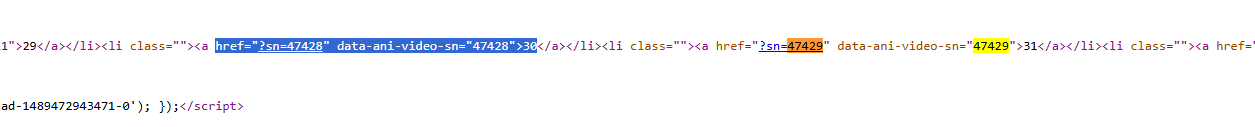

In [ ]:
# 錯誤範例

import urllib.request as req
url = "https://ani.gamer.com.tw/animeVideo.php?sn=47221"
resp = req.urlopen(url)
content = resp.read()
print(content)

# 回傳HTTP Error 403: Forbidden 因為沒有放入信封,

HTTPError: HTTP Error 403: Forbidden

如果回傳 HTTPError: HTTP Error 403: Forbidden
最常被檢查
要求標頭的 user-agent

有時候:
referrer 上一頁的版本
accept-language: 例如goole 針對不同地區給予不同的首頁


In [ ]:
# HTTP狀態碼的開頭
# 2: 成功
# 3: 轉址
# 4: 錯誤
# 404: Not Found
# 403: Forbidden
# 1. IP ban: 很肆無忌憚過
# 2. 人家覺得你不是瀏覽器(妳跟瀏覽器送出的不一樣=Headers沒加完)
# 問題: 網址+信封(headers)
# 回應: 回復+信封(headers)
# 以下丟到pycharm執行, baha的動畫首頁是有封鎖海外ip的
import urllib.request as req
url = "https://ani.gamer.com.tw/animeVideo.php?sn=47221"

h = {
    "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36 Edg/148.0.0.0"
}
r = req.Request(url, headers=h)
resp = req.urlopen(r)
content = resp.read()
print(content)

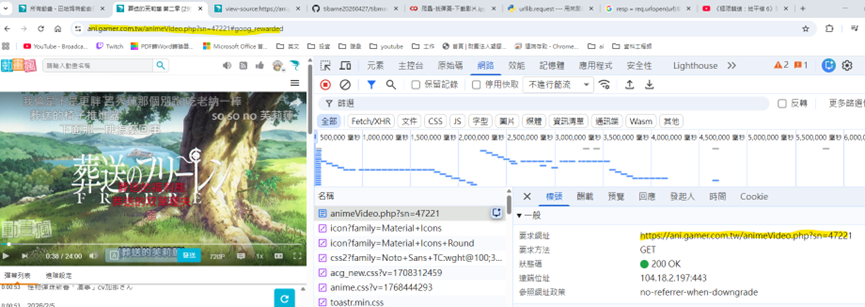